In [1]:
import os

if "PATH_SET" not in locals():
    os.chdir("..")
    PATH_SET = True

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style

import torch


from helpers.geographic_setup import (
    design_space_full,
    design_space_shoulder,
    topo_data,
    concave_hull_full,
    convex_hull_shoulder,
)
from helpers.helper_functions import (
    get_design_information,
    concave_hull2D_prior_dist_constructor,
)
from helpers.plotting import plot_topography

style.use(
    "https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle"
)

In [2]:
from pandas.errors import ParserError

# Initialize empty list to store dataframes
dfs = []

# Walk through all subdirectories
for root, dirs, files in tqdm(
    os.walk("generate_designs/data"),
    desc="Reading CSV files",
    total=len(os.listdir("generate_designs/data")),
):
    if "design_data.csv" in files:
        # Read the CSV file and append to list
        file_path = os.path.join(root, "design_data.csv")
        if file_path == "generate_designs/data/design_data.csv":
            continue

        try:
            df = pd.read_csv(file_path)
        except ParserError:
            print(f"Error reading {file_path}")
            continue

        dfs.append(df)

# Filter out empty DataFrames
dfs = [df for df in dfs if not df.empty]

# Add explicit dtype conversion after concatenation
combined_df = pd.concat(dfs, ignore_index=True).convert_dtypes()
combined_df.to_csv("generate_designs/data/design_data.csv", index=False)

# Get all column names except the specified ones
group_columns = [
    col
    for col in combined_df.columns
    if col not in ["design", "N_rec", "EIG", "EIG_ref", "runtime", "EIG_candidates"]
]
# Group by these columns
grouped_df = combined_df.groupby(group_columns).size().reset_index(name="count")


# Apply styling to highlight rows where count is less than 10
# Create a function that applies different background colors based on counts
def highlight_low_counts(s):
    if s["count"] < 9:
        return [
            "color: #cc0000" for _ in range(len(s))
        ]  # Light red background with dark red text
    elif s["count"] < 14:
        return [
            "color: #7f6000" for _ in range(len(s))
        ]  # Light yellow background with dark yellow text
    else:
        return ["" for _ in range(len(s))]


# Apply styling and display
styled_df = grouped_df.style.apply(highlight_low_counts, axis=1)
# display(styled_df)

print(f"Total number of designs: {grouped_df['count'].sum()}")
# Count the number of design scenarios with fewer than 10 designs
missing_designs = grouped_df[grouped_df["count"] < 9]
print(f"Number of scenarios with missing designs: {len(missing_designs)}")

Reading CSV files:   0%|          | 0/455 [00:00<?, ?it/s]

Total number of designs: 6663
Number of scenarios with missing designs: 0


In [3]:
combined_df[combined_df.N_rec > 45].groupby(
    ["study_area", "model_prior", "velocity_model", "EIG_method", "drop_mean"]
).size().reset_index(name="count")["count"].sum()

# np.int64(533)

np.int64(45)

In [4]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(styled_df)

In [5]:
from generate_designs.scenarios import scenarios

N_designs_total = np.sum([int(s["N_rec_max"]) - 1 for s in scenarios])

print(
    f"Currently calculated designs: {grouped_df['count'].sum()} out of {N_designs_total} ({100 * grouped_df['count'].sum() / N_designs_total:.0f}%)"
)
# Create a progress bar to visualize completion status
missing_count = len(missing_designs)
total_scenarios = len(scenarios)
completed_count = grouped_df["count"].sum()
completion_percentage = completed_count / N_designs_total

# Create ASCII progress bar
bar_length = 50
filled_length = int(bar_length * completion_percentage)
bar = "█" * filled_length + "░" * (bar_length - filled_length)

print(f"Progress: |{bar}| {completion_percentage:.1%}")
print(
    f"Number of scenarios with missing designs: {missing_count} out of {total_scenarios} scenarios"
)
print(
    f"Number of designs: {completed_count} out of {N_designs_total} designs ({N_designs_total - completed_count} missing)"
)

# Show scenarios with fewest designs (most critical gaps)
if not missing_designs.empty:
    print("\nMost critical missing scenarios:")
    critical_scenarios = missing_designs.sort_values("count").head(5)
    for i, row in critical_scenarios.iterrows():
        print(
            f"- {row['study_area']}, {row['model_prior']}, {row['EIG_method']}, EIG_N={row['EIG_N']}, {row['optimisation']}: {row['count']} designs"
        )

Currently calculated designs: 6663 out of 7044 (95%)
Progress: |███████████████████████████████████████████████░░░| 94.6%
Number of scenarios with missing designs: 0 out of 540 scenarios
Number of designs: 6663 out of 7044 designs (381 missing)


In [6]:
# Find scenarios that are not yet complete
incomplete_scenarios = missing_designs[missing_designs["count"] < 15]

# Create a more detailed view with percentage completion
incomplete_df = incomplete_scenarios.copy()

# Add a completion percentage column
incomplete_df["completion_pct"] = incomplete_df["count"].apply(
    lambda x: f"{(x / 10) * 100:.0f}%"
)

# Sort by count ascending (most critical first)
incomplete_df = incomplete_df.sort_values("count")

# For better display
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


# Create a colorful display with custom styling
def highlight_completion(val):
    """Highlight the completion percentage based on value"""
    count = int(val[:-1]) / 10
    if count < 0.5:
        return "background-color: #ffcccc; color: #990000"  # light red
    elif count < 0.7:
        return "background-color: #ffffcc; color: #666600"  # light yellow
    else:
        return "background-color: #e6ffcc; color: #336600"  # light green


# Display the styled dataframe
styled_incomplete = incomplete_df.style.map(
    highlight_completion, subset=["completion_pct"]
)

# Display the incomplete scenarios
display(styled_incomplete)

# Print summary statistics
print(f"\nTotal incomplete scenarios: {len(incomplete_df)}")
print(f"Average completion: {incomplete_df['count'].mean():.1f} out of 10 designs")
print(
    f"Remaining designs to complete: {10 * len(incomplete_df) - incomplete_df['count'].sum()}"
)

,study_area,model_prior,velocity_model,vel_sigma,noise_correlation,drop_mean,drop_gradient,optimisation,EIG_method,EIG_N,count,completion_pct



Total incomplete scenarios: 0
Average completion: nan out of 10 designs
Remaining designs to complete: 0


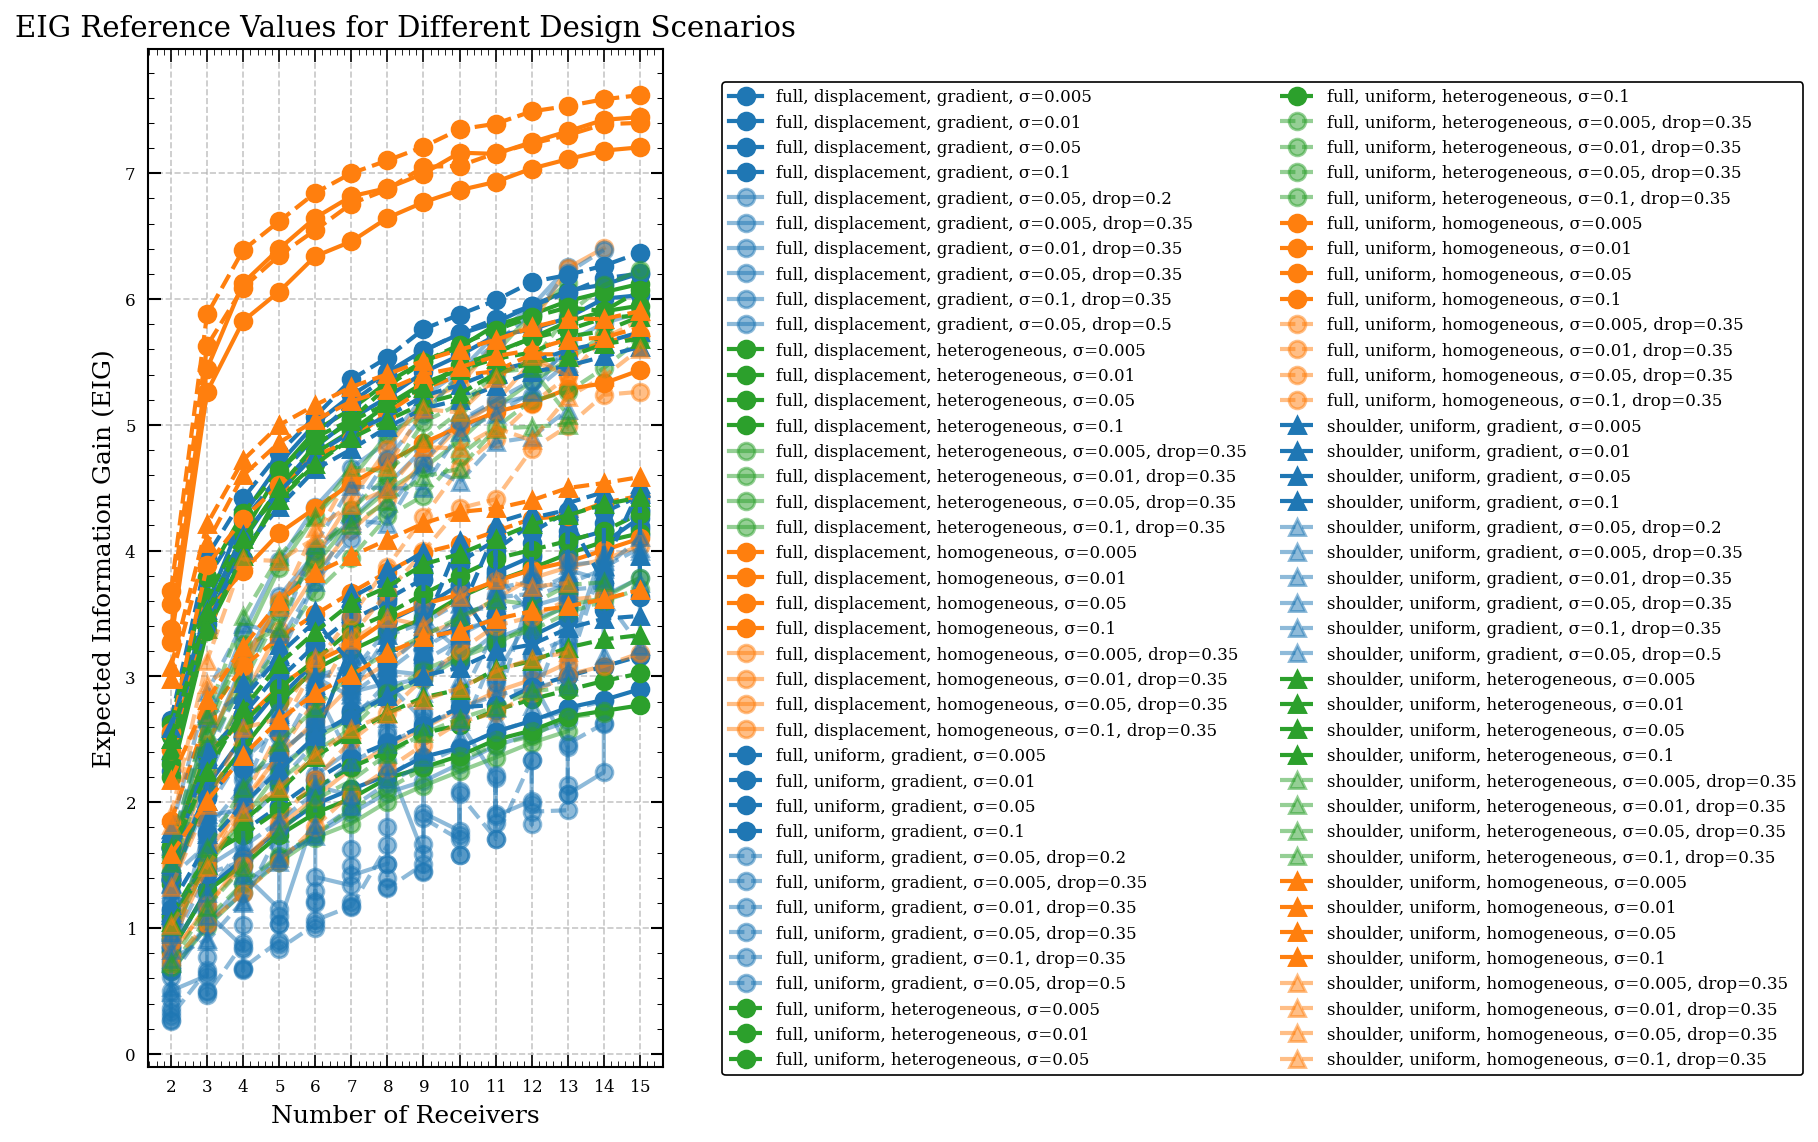

In [7]:
import matplotlib.pyplot as plt

# Set figure size and style
plt.figure(figsize=(12, 8))

# Create a color palette for different velocity models
vel_model_colors = {
    "gradient": "tab:blue",
    "homogeneous": "tab:orange",
    "heterogeneous": "tab:green",
}

# Create markers for different study areas
study_area_markers = {
    "full": "o",  # circle for full study area
    "shoulder": "^",  # triangle for shoulder area
}

# Create line styles for different model priors
prior_linestyles = {"displacement": "-", "uniform": "--"}

# Filter dataframe to include only relevant rows (genetic optimization and NMC method with EIG_N=1000)
filtered_df = combined_df[
    (combined_df["optimisation"] == "genetic")
    & (combined_df["EIG_method"] == "NMC")
    & (combined_df["EIG_N"] == 1000)
]

# Group by relevant parameters
grouped_data = filtered_df.groupby(
    ["study_area", "model_prior", "velocity_model", "drop_mean", "vel_sigma"]
)

# For each group, plot the EIG reference values against the number of receivers
for name, group in grouped_data:
    study_area, model_prior, velocity_model, drop_mean, vel_sigma = name

    # Determine if this is an attenuation case
    has_attenuation = drop_mean > 0

    # Get marker and line style
    marker = study_area_markers[study_area]
    linestyle = prior_linestyles[model_prior]
    color = vel_model_colors[velocity_model]

    # Alpha is lower for attenuation cases to distinguish them
    alpha = 0.5 if has_attenuation else 1.0

    # Sort by N_rec to ensure proper line connections
    sorted_group = group.sort_values("N_rec")

    # Create label
    label = f"{study_area}, {model_prior}, {velocity_model}, σ={vel_sigma}"
    if has_attenuation:
        label += f", drop={drop_mean}"

    # Plot the data
    plt.plot(
        sorted_group["N_rec"],
        sorted_group["EIG_ref"],
        marker=marker,
        linestyle=linestyle,
        color=color,
        alpha=alpha,
        linewidth=2,
        markersize=8,
        label=label,
    )

# Add legend with smaller font size and multiple columns
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, ncol=2)

# Add labels and title
plt.xlabel("Number of Receivers", fontsize=12)
plt.ylabel("Expected Information Gain (EIG)", fontsize=12)
plt.title("EIG Reference Values for Different Design Scenarios", fontsize=14)

# Set x-axis to show only integer values
plt.xticks(sorted(filtered_df["N_rec"].unique()))

# Add grid
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
def plot_design_list(design_list, N_rec_list):
    # Create figure
    fig, axes = plt.subplots(1, len(N_rec_list), figsize=(len(N_rec_list) * 2, 2))
    fig.set_facecolor("white")

    # Determine study area for visualization adjustments
    study_area = design_list.get("study_area", "full")

    # Plot each design
    for i, irec in enumerate(N_rec_list):
        ax = axes[i]

        try:
            design = design_list["design"][irec - 2]  # Adjust for zero-based index

            # print(design)

            ax.scatter(
                design[:, 0],
                design[:, 1],
                c="tab:red",
                s=30,
                marker="^",
                linewidths=0.5,
            )

            ax.set_title(f"N_rec: {irec}, EIG: {design_list['EIG_ref'][irec - 2]:.2f}")

            # Plot appropriate hull based on study area
            if study_area == "full":
                ax.plot(
                    concave_hull_full.shapley_poly.exterior.coords.xy[0],
                    concave_hull_full.shapley_poly.exterior.coords.xy[1],
                    color="k",
                    linewidth=1.0,
                    linestyle="--",
                    zorder=20,
                    alpha=1.0,
                )
            elif study_area == "shoulder":
                ax.plot(
                    convex_hull_shoulder.shapley_poly.exterior.coords.xy[0],
                    convex_hull_shoulder.shapley_poly.exterior.coords.xy[1],
                    color="k",
                    linewidth=1.0,
                    linestyle="--",
                    zorder=20,
                    alpha=1.0,
                )

            ax.set_aspect("equal")
            ax.set_xticks([])
            ax.set_yticks([])

            # Set appropriate limits based on study area
            if study_area == "shoulder":
                ax.set_xlim(450, 1700)
                ax.set_ylim(1200, 1700)
        except IndexError:
            ax.set_visible(False)

        plot_topography(ax, topo_data, contours=False)

    plt.tight_layout()
    plt.show()

In [9]:
# test_scenario_1 = dict(
#     study_area='full', model_prior='displacement', velocity_model='gradient',
#     vel_sigma=0.05, noise_correlation=100.0,
#     drop_mean=0.0, drop_gradient=0.0,
#     optimisation='genetic', EIG_method='NMC', EIG_N=1000,
# )
# test_scenario_2 = dict(
#     study_area='full', model_prior='displacement', velocity_model='gradient',
#     vel_sigma=0.05, noise_correlation=100.0,
#     drop_mean=0.35, drop_gradient=-30.0,
#     optimisation='genetic', EIG_method='NMC', EIG_N=1000,
# )
# N_rec_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# # N_rec_list = [1, 2, 3, 4, 5, 6]


# plot_design_list(get_design_information(combined_df, test_scenario_1), N_rec_list)
# plot_design_list(get_design_information(combined_df, test_scenario_2), N_rec_list)

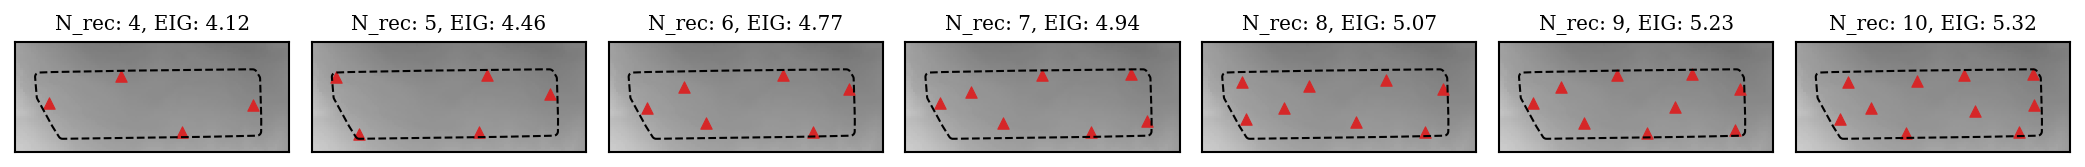

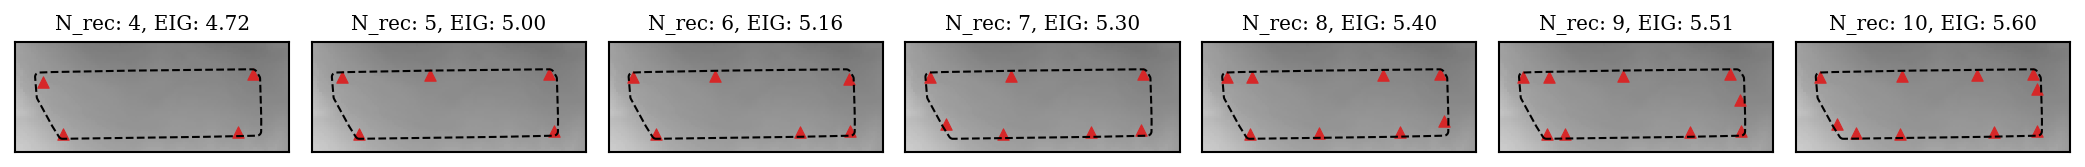

In [10]:
test_scenario_1 = dict(
    study_area="shoulder",
    model_prior="uniform",
    velocity_model="gradient",
    vel_sigma=0.005,
    noise_correlation=100.0,
    # drop_mean=0.35, drop_gradient=-30.0,
    drop_mean=0.0,
    drop_gradient=0.0,
    optimisation="genetic",
    EIG_method="NMC",
    EIG_N=1000,
)

test_scenario_2 = dict(
    study_area="shoulder",
    model_prior="uniform",
    velocity_model="homogeneous",
    vel_sigma=0.005,
    noise_correlation=100.0,
    # drop_mean=0.35, drop_gradient=-30.0,
    drop_mean=0.0,
    drop_gradient=0.0,
    optimisation="genetic",
    EIG_method="NMC",
    EIG_N=1000,
)


# N_rec_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N_rec_list = [4, 5, 6, 7, 8, 9, 10]


plot_design_list(get_design_information(combined_df, test_scenario_1), N_rec_list)
plot_design_list(get_design_information(combined_df, test_scenario_2), N_rec_list)

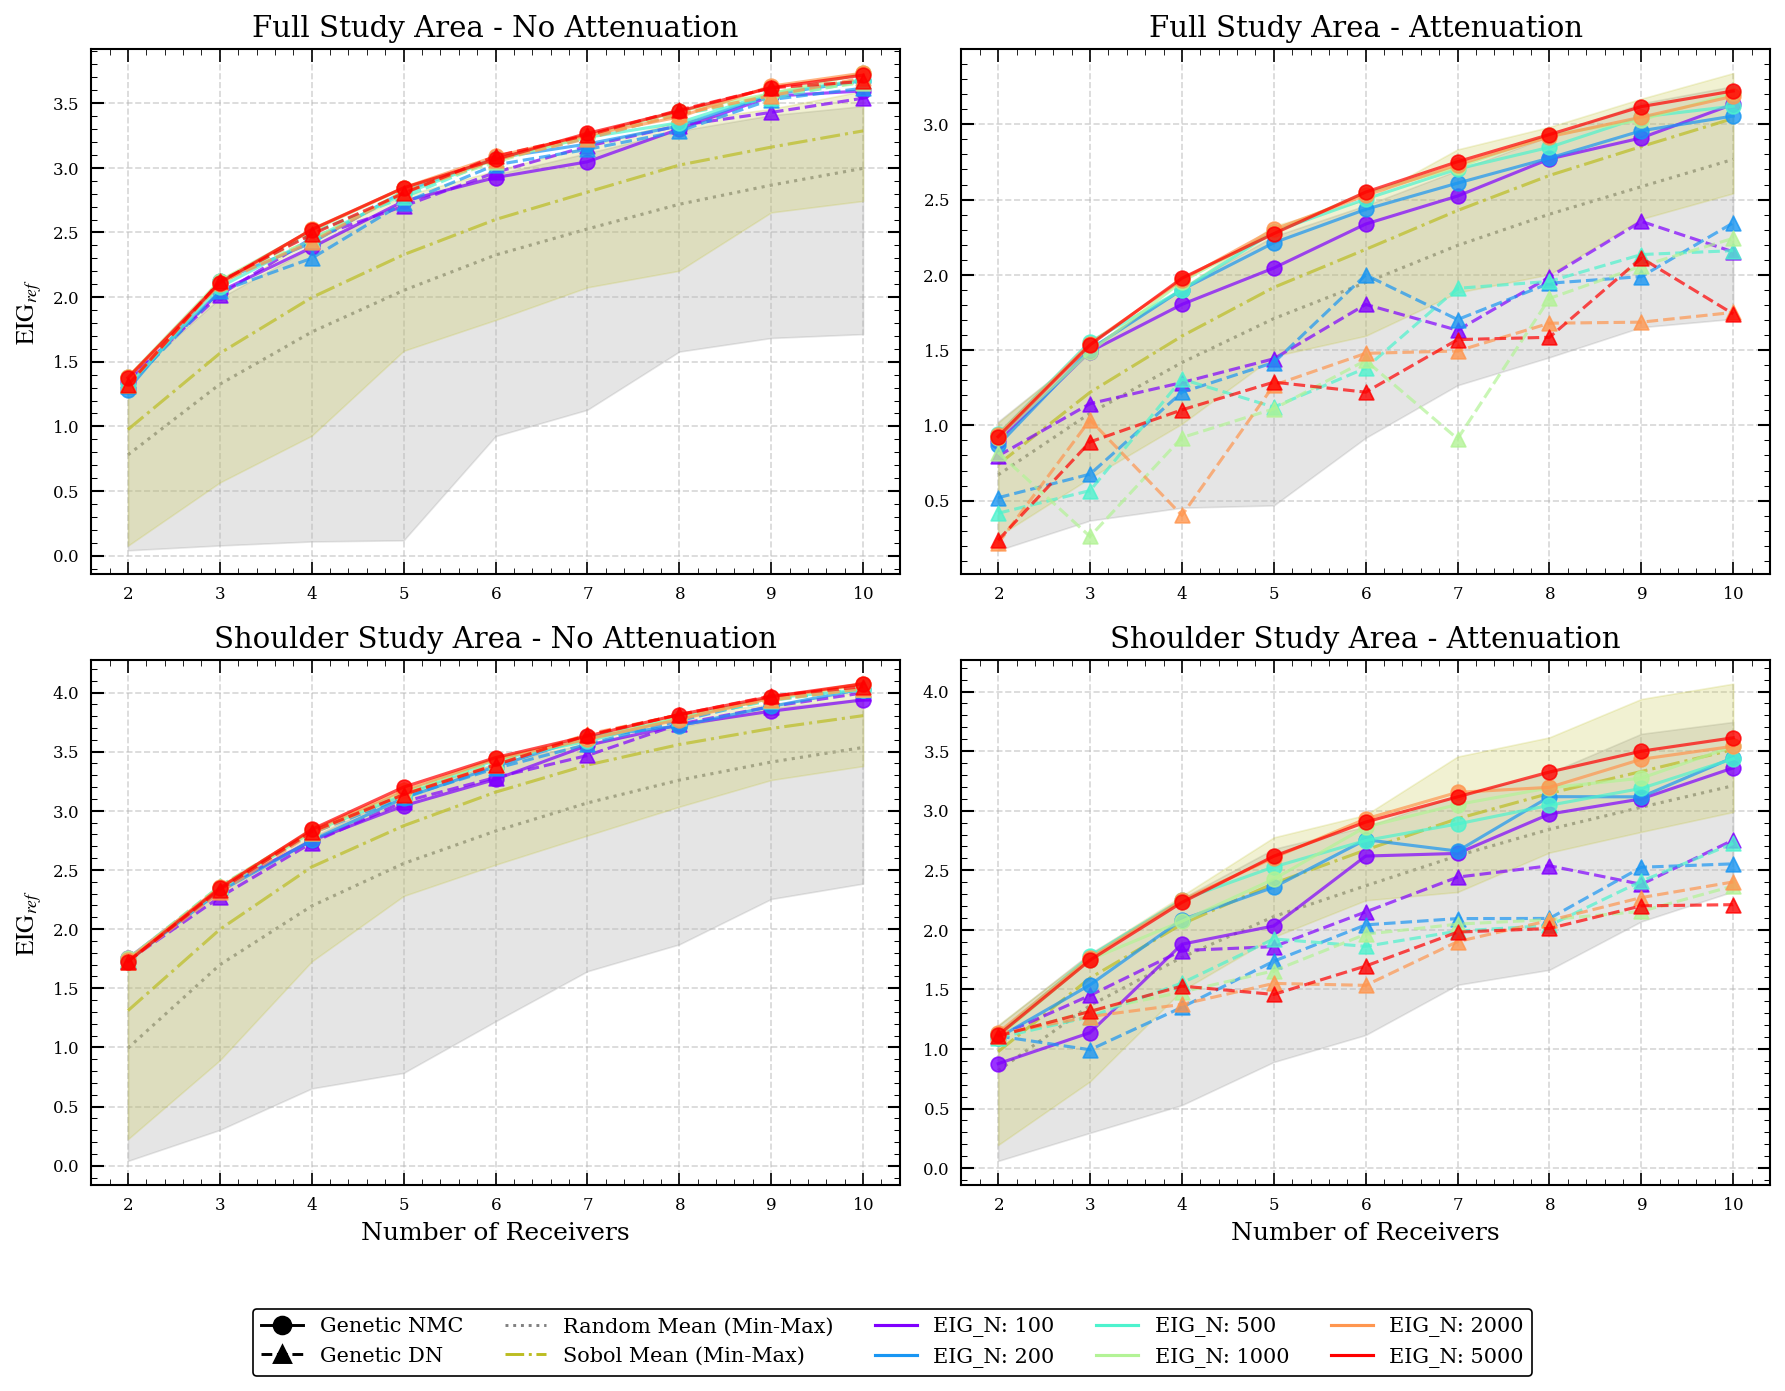

In [11]:
import ast
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# Create a function that takes N_rec as a parameter
def plot_eig_comparison(N_rec_max=10, normalize=False):
    # Create a figure with two rows of subplots (full and shoulder)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Define markers for methods and line styles for drop values
    markers = {"NMC": "o", "DN": "^"}  # Different markers for methods
    linestyles = {"NMC": "-", "DN": "--"}  # Different line styles for drop values

    # Define EIG_N values and create a color gradient using rainbow colormap
    eig_n_values = sorted(combined_df["EIG_N"].unique())
    eig_n_colors = {
        val: plt.cm.rainbow(i / (len(eig_n_values) - 1))
        for i, val in enumerate(eig_n_values)
    }

    # Plot each subplot separately
    for row_idx, study_area in enumerate(["full", "shoulder"]):
        for col_idx, drop_val in enumerate([0.0, 0.35]):
            ax = axes[row_idx, col_idx]

            # Filter data for this study_area and drop_mean value
            area_drop_df = combined_df[
                (combined_df["study_area"] == study_area)
                & (
                    combined_df["model_prior"]
                    == ("uniform" if study_area == "shoulder" else "displacement")
                )
                & (combined_df["velocity_model"] == "gradient")
                & (combined_df["vel_sigma"] == 0.05)
                & (combined_df["noise_correlation"] == 100.0)
                & (combined_df["drop_mean"] == drop_val)
                & (combined_df["drop_gradient"] == (-30.0 if drop_val == 0.35 else 0.0))
                & (combined_df["N_rec"] <= N_rec_max)
            ]  # Apply N_rec_max filter

            # Split the data by optimization method
            genetic_df = area_drop_df[area_drop_df["optimisation"] == "genetic"]
            random_df = area_drop_df[area_drop_df["optimisation"] == "random"]
            sobol_df = area_drop_df[area_drop_df["optimisation"] == "sobol"]

            # Get normalization values if normalize is True
            if normalize:
                # Get normalization values for each N_rec (using NMC as reference)
                norm_values = {}
                for n_rec in sorted(area_drop_df["N_rec"].unique()):
                    nmc_subset = area_drop_df[(area_drop_df["N_rec"] == n_rec)]
                    if not nmc_subset.empty:
                        # Use max of values as normalization factor
                        norm_values[n_rec] = nmc_subset["EIG_ref"].max()
                    else:
                        # If no values for this N_rec, use 1.0 (no normalization)
                        norm_values[n_rec] = 1.0

            # Plot genetic data (NMC and DN methods)
            for eig_method in sorted(genetic_df["EIG_method"].unique()):
                for eig_n in sorted(genetic_df["EIG_N"].unique()):
                    subset = genetic_df[
                        (genetic_df["EIG_method"] == eig_method)
                        & (genetic_df["EIG_N"] == eig_n)
                    ]

                    if not subset.empty:
                        # Sort by N_rec to ensure proper line connections
                        subset = subset.sort_values("N_rec")

                        # Apply normalization if enabled
                        if normalize:
                            # Normalize each row's EIG_ref by the normalization factor for its N_rec
                            y_values = (
                                np.array(
                                    [
                                        (row["EIG_ref"] - norm_values[row["N_rec"]])
                                        / norm_values[row["N_rec"]]
                                        for _, row in subset.iterrows()
                                    ]
                                )
                                * 100
                            )
                        else:
                            y_values = subset["EIG_ref"]

                        # Plot scatter points with markers based on method
                        ax.scatter(
                            subset["N_rec"],
                            y_values,
                            color=eig_n_colors[eig_n],
                            marker=markers[eig_method],
                            s=50,
                            alpha=0.8,
                            zorder=eig_n + 10,
                        )

                        # Connect points with lines - line style based on drop value
                        ax.plot(
                            subset["N_rec"],
                            y_values,
                            color=eig_n_colors[eig_n],
                            linestyle=linestyles[eig_method],
                            alpha=0.7,
                            linewidth=1.5,
                            zorder=eig_n + 10,
                        )

            # Plot mean, min and max for random and sobol designs
            for opt_method, df, zorder_base in [
                ("random", random_df, 1),
                ("sobol", sobol_df, 5),
            ]:
                # Calculate mean, min, and max for each N_rec and EIG_N
                for eig_n in sorted(df["EIG_N"].unique()):
                    n_rec_values = sorted(df["N_rec"].unique())
                    means = []
                    mins = []
                    maxs = []

                    for n_rec in n_rec_values:
                        subset = df[(df["EIG_N"] == eig_n) & (df["N_rec"] == n_rec)]
                        if not subset.empty:
                            if normalize:
                                values = np.array(
                                    ast.literal_eval(subset["EIG_candidates"].iloc[0])
                                )
                                normalized_values = (
                                    (values - norm_values[n_rec])
                                    / norm_values[n_rec]
                                    * 100
                                )
                                means.append(np.mean(normalized_values))
                                mins.append(np.min(normalized_values))
                                maxs.append(np.max(normalized_values))
                            else:
                                values = np.array(
                                    ast.literal_eval(subset["EIG_candidates"].iloc[0])
                                )
                                means.append(np.mean(values))
                                mins.append(np.min(values))
                                maxs.append(np.max(values))
                        else:
                            means.append(np.nan)
                            mins.append(np.nan)
                            maxs.append(np.nan)

                    # Filter out missing values
                    valid_indices = ~np.isnan(means)
                    if np.any(valid_indices):
                        valid_n_recs = np.array(n_rec_values)[valid_indices]
                        valid_means = np.array(means)[valid_indices]
                        valid_mins = np.array(mins)[valid_indices]
                        valid_maxs = np.array(maxs)[valid_indices]

                        # Plot mean line
                        label = f"{opt_method.capitalize()} (EIG_N: {eig_n})"
                        color = "grey" if opt_method == "random" else "tab:olive"
                        linestyle = ":" if opt_method == "random" else "-."

                        ax.plot(
                            valid_n_recs,
                            valid_means,
                            color=color,
                            linestyle=linestyle,
                            alpha=0.7,
                            linewidth=1.5,
                            label=label,
                            zorder=zorder_base,
                        )

                        # Plot filled region for min-max range
                        ax.fill_between(
                            valid_n_recs,
                            valid_mins,
                            valid_maxs,
                            color=color,
                            alpha=0.2,
                            zorder=zorder_base - 1,
                        )

            # Add labels
            if row_idx == 1:
                ax.set_xlabel("Number of Receivers", fontsize=12)

            if col_idx == 0:
                ax.set_ylabel(
                    r"$\mathrm{EIG}_{ref}$ (% of max)"
                    if normalize
                    else r"$\mathrm{EIG}_{ref}$",
                    fontsize=12,
                )

            # Add titles
            if row_idx == 0:
                if drop_val == 0.0:
                    ax.set_title("Full Study Area - No Attenuation", fontsize=14)
                else:
                    ax.set_title("Full Study Area - Attenuation", fontsize=14)
            else:
                if drop_val == 0.0:
                    ax.set_title("Shoulder Study Area - No Attenuation", fontsize=14)
                else:
                    ax.set_title("Shoulder Study Area - Attenuation", fontsize=14)

            if normalize:
                ax.set_ylim(-20, 5)

            # Set x-axis to show whole numbers
            ax.set_xticks(sorted(list(set(area_drop_df["N_rec"].unique()))))
            ax.grid(True, linestyle="--", alpha=0.5)

    # Create custom legend elements
    legend_elements = []

    # Method legend (markers)
    for method, marker in markers.items():
        legend_elements.append(
            Line2D(
                [0],
                [0],
                color="black",
                marker=marker,
                linestyle=linestyles[method],
                markersize=8,
                label=f"Genetic {method}",
            )
        )

    # Random and Sobol line styles
    legend_elements.append(
        Line2D(
            [0],
            [0],
            color="grey",
            linestyle=":",
            markersize=8,
            label="Random Mean (Min-Max)",
        )
    )
    legend_elements.append(
        Line2D(
            [0],
            [0],
            color="tab:olive",
            linestyle="-.",
            markersize=8,
            label="Sobol Mean (Min-Max)",
        )
    )

    # EIG_N legend (colors)
    for eig_n, color in eig_n_colors.items():
        legend_elements.append(
            Line2D([0], [0], color=color, lw=1.5, label=f"EIG_N: {eig_n}")
        )

    # Add the legend to the figure
    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.1),
        fancybox=True,
        ncol=5,
        fontsize=10,
    )

    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.show()


# Call the function with a specific N_rec_max value
plot_eig_comparison(N_rec_max=10)

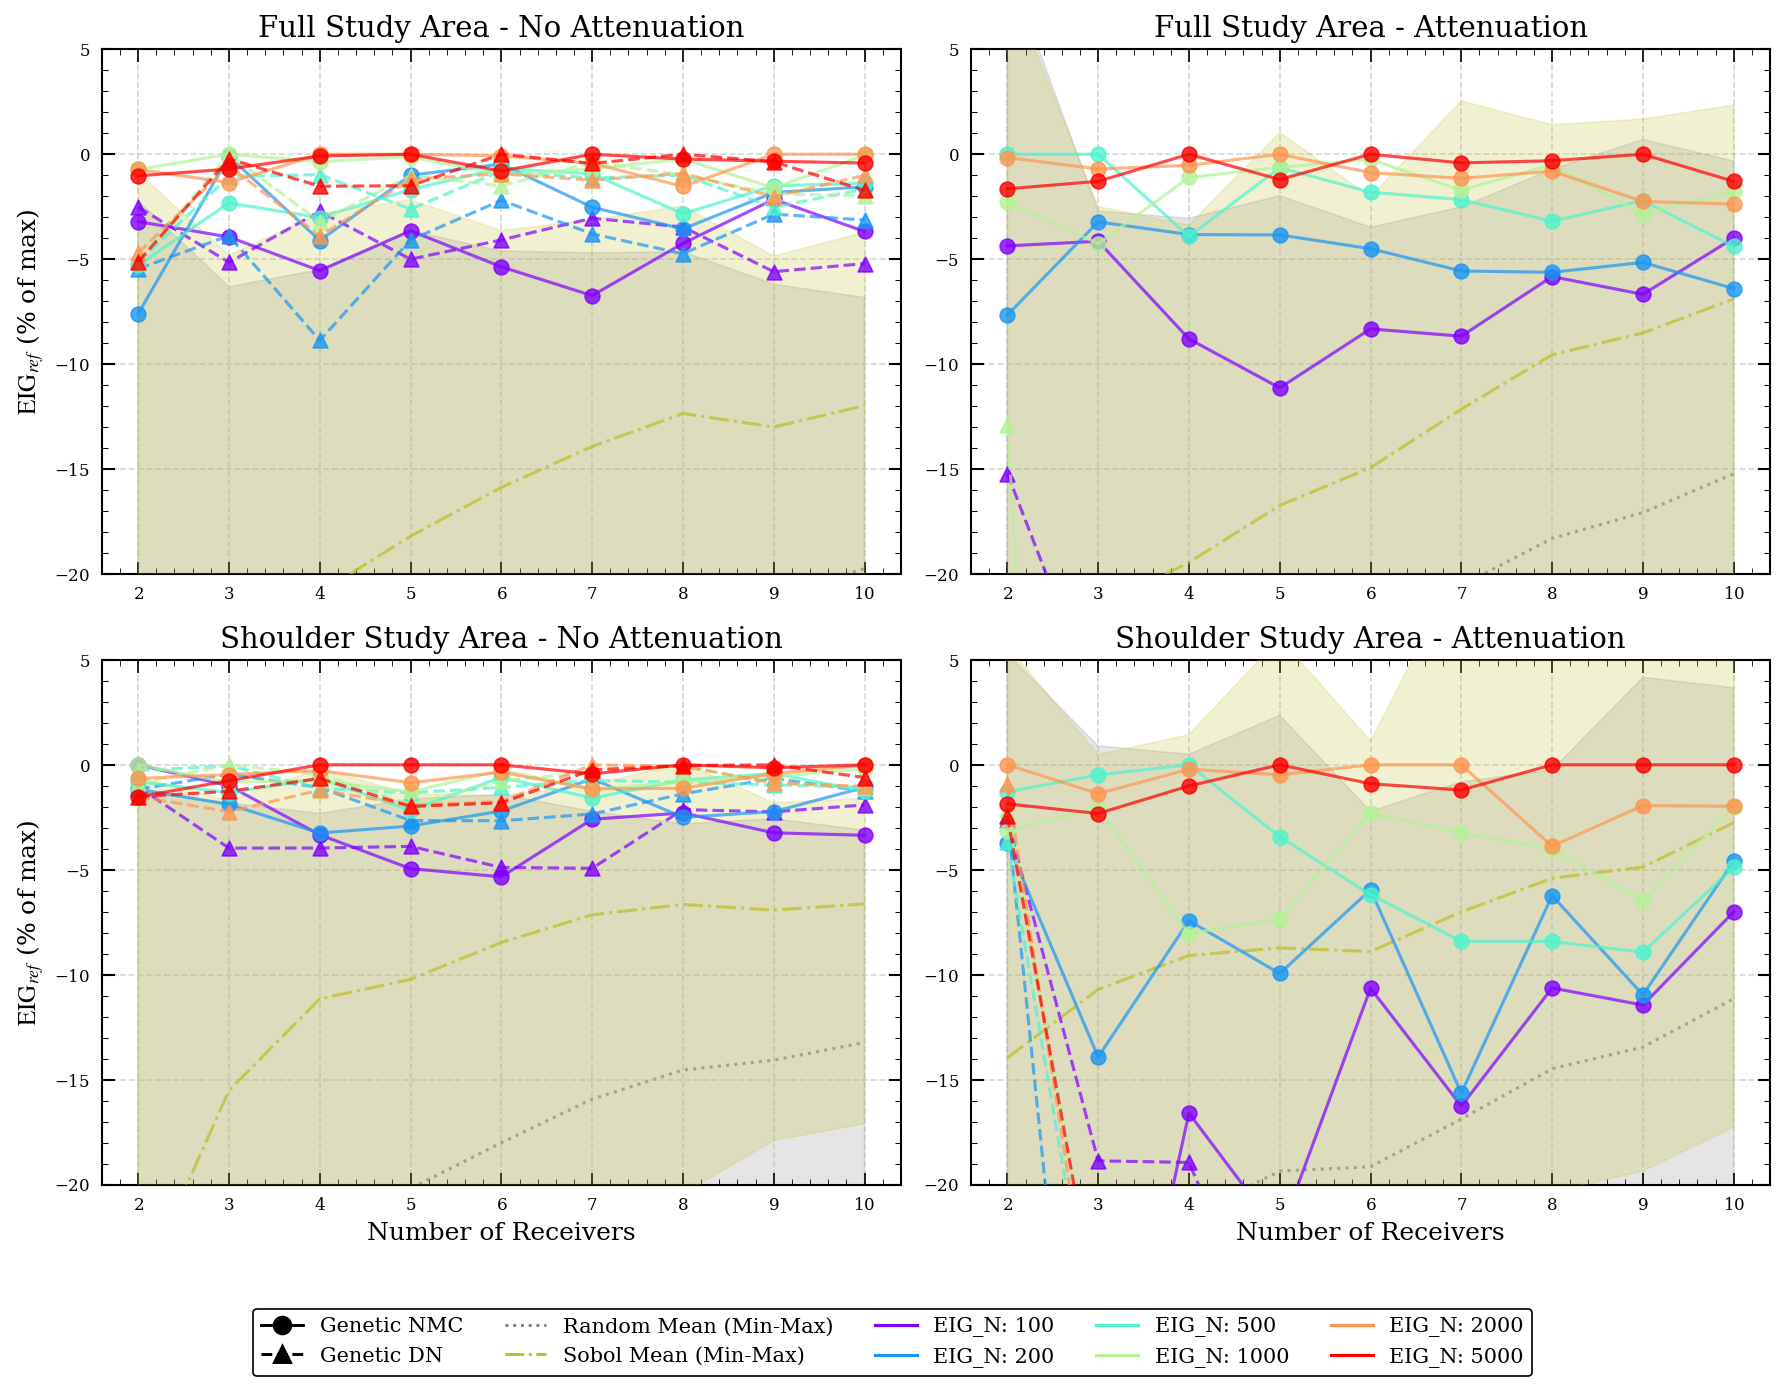

In [12]:
plot_eig_comparison(N_rec_max=10, normalize=True)

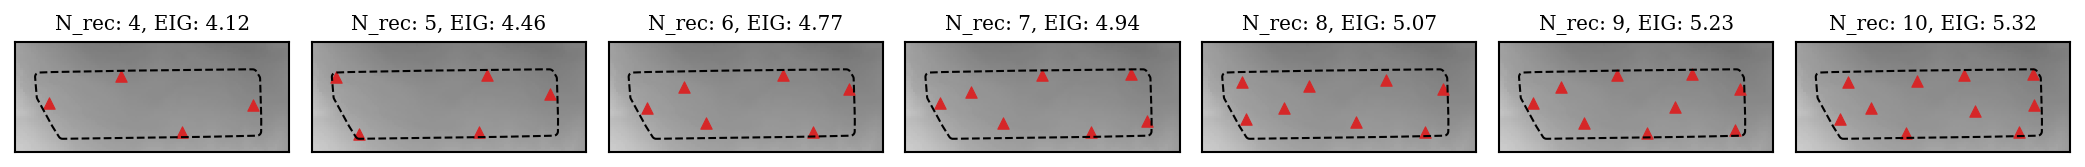

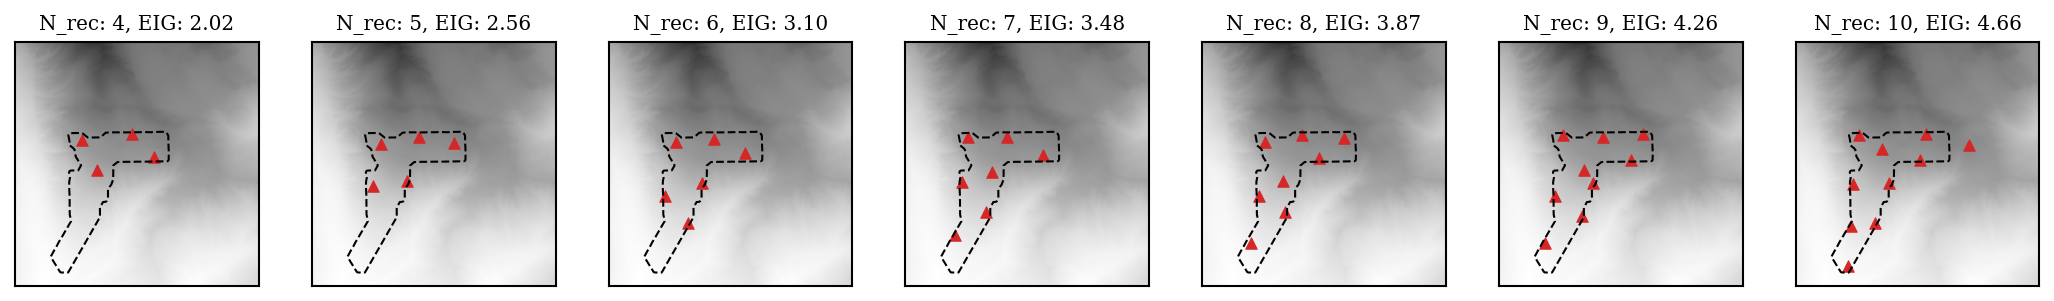

In [13]:
test_scenario_1 = dict(
    study_area="shoulder",
    model_prior="uniform",
    velocity_model="gradient",
    vel_sigma=0.005,
    noise_correlation=100.0,
    # drop_mean=0.35, drop_gradient=-30.0,
    drop_mean=0.0,
    drop_gradient=0.0,
    optimisation="genetic",
    EIG_method="NMC",
    EIG_N=1000,
)

test_scenario_2 = dict(
    study_area="full",
    model_prior="uniform",
    velocity_model="homogeneous",
    vel_sigma=0.005,
    noise_correlation=100.0,
    drop_mean=0.35,
    drop_gradient=-30.0,
    # drop_mean=0.0, drop_gradient=0.0,
    optimisation="genetic",
    EIG_method="NMC",
    EIG_N=1000,
)


# N_rec_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N_rec_list = [4, 5, 6, 7, 8, 9, 10]


plot_design_list(get_design_information(combined_df, test_scenario_1), N_rec_list)
plot_design_list(get_design_information(combined_df, test_scenario_2), N_rec_list)

In [14]:
scen_columns = [
    "study_area",
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "drop_mean",
    "drop_gradient",
    "attenuation",
    "optimisation",
    "EIG_method",
    "EIG_N",
]

stat_columns = [
    "mean_x",
    "mean_y",
    "mean_z",
    "std_x",
    "std_y",
    "std_z",
    "std",
    "distance_mean",
    "distance_map",
    "p_posterior",
    "posterior_entropy",
    "posterior_information",
    "prior_entropy",
    "prior_information",
]

In [15]:
summary_statistics_file = "benchmark_designs/full/data/summary_statistics.csv"

if os.path.exists(summary_statistics_file):
    summary_statistics = pd.read_csv(summary_statistics_file)
    print(f"Loaded summary statistics from {summary_statistics_file}")
else:
    raise FileNotFoundError(
        f"Summary statistics file not found: {summary_statistics_file}"
    )
summary_statistics = summary_statistics[
    summary_statistics["optimisation"].isin(["iterative", "genetic"])]

summary_statistics = summary_statistics[
    ~((summary_statistics['EIG_method'] == 'DN') & (summary_statistics['drop_mean'] != 0.0))
]
summary_statistics['std'] = np.sqrt(
    summary_statistics['std_x'] ** 2 + summary_statistics['std_y'] **
    2 + summary_statistics['std_z'] ** 2
)

summary_statistics["attenuation"] = summary_statistics["drop_mean"].apply(
    lambda x: "yes" if x > 0 else "no"
)
summary_statistics['drop_gradient'] = -summary_statistics['drop_gradient']

design_stats = summary_statistics.groupby(scen_columns + ["N_rec"]).agg(
    {
        "design": "first",
        "mean_x": "mean",
        "mean_y": "mean",
        "mean_z": "mean",
        "std_x": "mean",
        "std_y": "mean",
        "std_z": "mean",
        "std": "mean",
        "distance_mean": "mean",
        "distance_map": "mean",
        "p_posterior": "mean",
        "posterior_entropy": "mean",
        "posterior_information": "mean",
        "prior_entropy": "mean",
        "prior_information": "mean",
    }
).reset_index()


Loaded summary statistics from benchmark_designs/full/data/summary_statistics.csv


In [16]:
sdf_filter = (
    (design_stats["study_area"] == "full")
    & (design_stats["N_rec"] == 4)
    & (design_stats["EIG_N"] == 1000)
)

design_stats = design_stats[sdf_filter].reset_index(drop=True)


In [17]:
import os

random_stats_file = "benchmark_designs/full/data/random_stats.csv"
sobol_stats_file = "benchmark_designs/full/data/sobol_stats.csv"

if os.path.exists(random_stats_file):
    random_stats_df = pd.read_csv(random_stats_file)
else:
    raise FileNotFoundError(
        f"Random stats file not found: {random_stats_file}. Please generate it first."
    )
    
if os.path.exists(sobol_stats_file):
    sobol_stats_df = pd.read_csv(sobol_stats_file)
else:
    raise FileNotFoundError(
        f"Sobol stats file not found: {sobol_stats_file}. Please generate it first."
    )

random_stats_df['std'] = np.sqrt(
    random_stats_df['std_x'] ** 2 + random_stats_df['std_y'] ** 2 + random_stats_df['std_z'] ** 2
) 
sobol_stats_df['std'] = np.sqrt(
    sobol_stats_df['std_x'] ** 2 + sobol_stats_df['std_y'] ** 2 + sobol_stats_df['std_z'] ** 2
)

random_stats_df = random_stats_df[
    random_stats_df['N_rec'] <= 10
]
sobol_stats_df = sobol_stats_df[
    sobol_stats_df['N_rec'] <= 10
]

# Add design_index to random_stats_df and sobol_stats_df
# design_index is the index within each (N_rec, event_index) group


def add_design_index(df):
    # If already present, do not add again
    if "design_index" in df.columns:
        return df
    # Assign design_index within each (N_rec, event_index) group
    df = df.copy()
    df["design_index"] = df.groupby(["N_rec", "event_index"]).cumcount()
    return df


random_stats_df = add_design_index(random_stats_df)
sobol_stats_df = add_design_index(sobol_stats_df)

random_stats_df = random_stats_df[random_stats_df["N_rec"] == 4]
sobol_stats_df = sobol_stats_df[sobol_stats_df["N_rec"] == 4]

# First, group by N_rec and event_index, then average over events for each design_index
random_grouped = (
    random_stats_df.groupby(
        [
            "N_rec",
            "design_index",
            "design",
        ]
    )[stat_columns]
    .mean()
    .reset_index()
)

sobol_grouped = (
    sobol_stats_df.groupby(
        [
            "N_rec",
            "design_index",
            "design",
        ]
    )[stat_columns]
    .mean()
    .reset_index()
)

design_stats_grouped = (
    design_stats.groupby(
        scen_columns + ["N_rec"] + ["design"]
    )[stat_columns]
    .mean()
    .reset_index()
)

random_grouped['EIG'] = random_grouped['posterior_information'] - random_grouped['prior_information']
sobol_grouped['EIG'] = sobol_grouped['posterior_information'] - sobol_grouped['prior_information']
design_stats_grouped['EIG'] = design_stats_grouped['posterior_information'] - design_stats_grouped['prior_information']

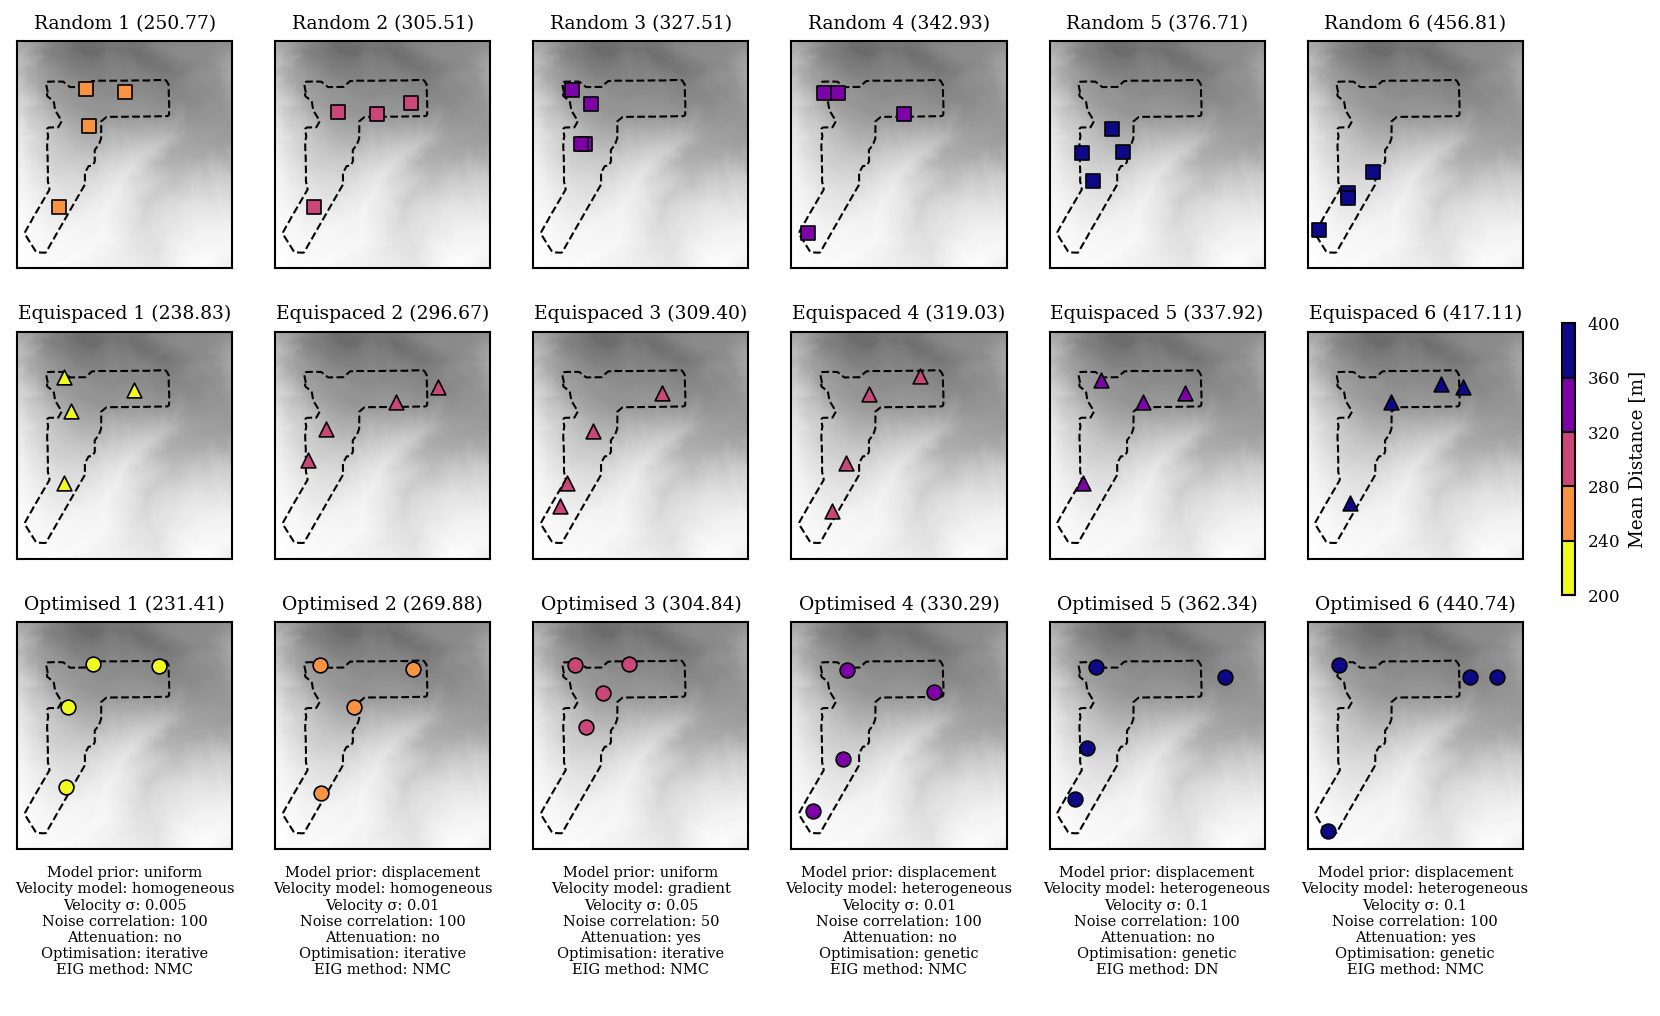

In [18]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# parameters
N = 6

# metric = "EIG"
# vmin, vmax = 0.7, 1.7

metric = "distance_mean"
vmin, vmax = 200.0, 400.0

n_colors = 5
base_cmap = plt.cm.plasma_r
colors = base_cmap(np.linspace(0, 1, n_colors))
cmap = ListedColormap(colors)
boundaries = np.linspace(vmin, vmax, n_colors + 1)
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

def to_numpy(d):
    """Convert a variety of design representations to an (M,2) numpy array (best-effort)."""
    if d is None:
        return np.empty((0, 2))
    # torch tensor
    if hasattr(d, "cpu") and callable(getattr(d, "cpu")):
        try:
            return d.cpu().numpy()
        except Exception:
            raise
    if isinstance(d, np.ndarray):
        return d
    try:
        arr = np.asarray(d)
        if arr.ndim == 2:
            return arr
    except Exception:
        raise
    try:
        parsed = ast.literal_eval(d)
        return np.array(parsed)
    except Exception:
        raise
    return np.array(d)

def select_evenly_spaced_indices(df, col, M):
    """
    Select M row indices from df approximately evenly spaced in df[col] (by quantiles).
    Uses interior quantiles to avoid repeatedly selecting exact min/max when you display the
    extreme 'best' in the first column.
    """
    if M <= 0:
        return []
    series = df[col].astype(float)
    # interior quantiles: M points evenly spaced between 0 and 1, excluding exact endpoints.
    quantiles = np.linspace(0.0, 1.0, M)
    qvals = series.quantile(quantiles).to_numpy()
    selected_idx = []
    for qv in qvals:
        distances = (series - qv).abs()
        if selected_idx:
            distances.iloc[selected_idx] = distances.max() + 1.0
        selected_idx.append(distances.idxmin())
    # return in increasing column order for left-to-right plotting
    selected = df.loc[selected_idx].sort_values(
        col, ascending=True).index.to_list()
    return selected

def _extract_design_from_row(row, group_name):
    """Try common ways to obtain the design object/array from a grouped row."""
    # direct 'design' column
    if "design" in row:
        return row["design"]
    # design_index -> try to find a matching design list in globals
    if "design_index" in row:
        idx = int(row.design_index)
        
        print(idx)

# assume grouped DataFrames are available: sobol_grouped, random_grouped, design_stats_grouped
groups = [
    ("random_grouped", "Random", "s", 75),
    ("sobol_grouped", "Equispaced", "^", 75),
    ("design_stats_grouped", "Optimised", "o", 60),
]

# create 4 rows: 3 rows of plots + 1 text row for optimized-design choices
fig, axes = plt.subplots(4, N, figsize=((3 * (N-0.5) + 2)*0.7, 3 * 4*0.7), sharex=True, sharey=True,
                            gridspec_kw=dict(height_ratios= [1, 1, 1, 0.4]))
                         
fig.set_facecolor("white")

for row_idx, (group_name, row_label, marker, best_size) in enumerate(groups):
    group = globals().get(group_name, None)

    # select N evenly spaced percentiles and plot them in columns 1..N
    idxs = select_evenly_spaced_indices(group, metric, N)
    for i in range(N):
        ax = axes[row_idx, i]
        try:
            sel_row = group.loc[idxs[i]]
            eig_val = float(sel_row[metric])
            design = _extract_design_from_row(sel_row, group_name)
        except Exception:
            raise
        d_np = to_numpy(design)
        if d_np.size:
            ax.scatter(
                d_np[:, 0],
                d_np[:, 1],
                color=cmap(norm(eig_val)),
                s=50,
                marker=marker,
                edgecolor="k",
                label=f"{row_label} {i+1}",
            )
        ax.set_title(f"{row_label} {i+1} ({eig_val:.2f})", fontsize=9)

# common styling and topo overlay for the three plot rows only
for ax_row in axes[:-1]:
    for ax in ax_row:
        try:
            plot_topography(ax, topo_data, contours=False)
        except Exception:
            raise
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(300, 2100)
        ax.set_ylim(0, 1900)
        try:
            ax.plot(
                concave_hull_full.shapley_poly.exterior.coords.xy[0],
                concave_hull_full.shapley_poly.exterior.coords.xy[1],
                color="k",
                linewidth=1.0,
                linestyle="--",
                zorder=0,
            )
        except Exception:
            raise

# -------------------------
# New: add a fourth row containing text with the design choices for the optimized designs
# -------------------------
# human-friendly labels for the metadata keys
label_map = {
    "model_prior": "Model prior",
    "velocity_model": "Velocity model",
    "vel_sigma": "Velocity σ",
    "noise_correlation": "Noise correlation",
    "attenuation": "Attenuation",
    "optimisation": "Optimisation",
    "EIG_method": "EIG method",
    # optional common extras
#     "drop_mean": "Drop mean",
#     "drop_gradient": "Drop gradient",
}

# try to get the selected rows from design_stats_grouped (if available)
ds_group = globals().get("design_stats_grouped", None)
ds_idxs = select_evenly_spaced_indices(ds_group, "EIG", N) if ds_group is not None else []

for i in range(N):
    ax = axes[3, i]
    ax.axis("off")  # text-only
    text_lines = []
    if ds_group is not None and ds_idxs and i < len(ds_idxs):
        try:
            r = ds_group.loc[ds_idxs[i]]
            # prefer to look both in the row and inside a nested 'design_meta' or similar if present
            for k in label_map.keys():
                nice_k = label_map.get(k, k)
                if k in r:
                    val = r[k]
                    text_lines.append(f"{nice_k}: {val}")
                else:
                    # sometimes metadata is stored in a nested dict column; try common names
                    if "design_meta" in r and isinstance(r["design_meta"], dict) and k in r["design_meta"]:
                        text_lines.append(f"{nice_k}: {r['design_meta'][k]}")
        except Exception:
            raise

    if not text_lines:
        display_text = "(no design metadata available)"
    else:
        display_text = "\n".join(text_lines)

    # center the text in the axes; adjust fontsize to fit
    ax.text(
        0.5,
        0.8,
        display_text,
        ha="center",
        va="center",
        fontsize=7,
        transform=ax.transAxes,
    )

# colorbar at right (adjusted for the taller figure)
cbar_ax = fig.add_axes([0.92, 0.13, 0.007, 0.82])
cbar_ax.set_aspect(20)
fig.colorbar(sm, cax=cbar_ax, label="Mean Distance [m]")


fig.savefig("figures/designs_comparison_full.png", dpi=300, bbox_inches="tight")
fig.savefig("figures/designs_comparison_full.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
scen_columns = [
    "study_area",
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "drop_mean",
    "drop_gradient",
    "attenuation",
    "optimisation",
    "EIG_method",
    "EIG_N",
]

stat_columns = [
    "mean_x",
    "mean_y",
    "std_x",
    "std_y",
    "std",
    "distance_mean",
    "distance_map",
    "p_posterior",
    "posterior_entropy",
    "posterior_information",
    "prior_entropy",
    "prior_information",
]

In [20]:
summary_statistics_file = "benchmark_designs/shoulder/data/summary_statistics.csv"

if os.path.exists(summary_statistics_file):
    summary_statistics = pd.read_csv(summary_statistics_file)
    print(f"Loaded summary statistics from {summary_statistics_file}")
else:
    raise FileNotFoundError(
        f"Summary statistics file not found: {summary_statistics_file}"
    )
summary_statistics = summary_statistics[
    summary_statistics["optimisation"].isin(["iterative", "genetic"])]

summary_statistics = summary_statistics[
    ~((summary_statistics['EIG_method'] == 'DN') & (summary_statistics['drop_mean'] != 0.0))
]
summary_statistics['std'] = np.sqrt(
    summary_statistics['std_x'] ** 2 + summary_statistics['std_y'] **
    2
)

summary_statistics["attenuation"] = summary_statistics["drop_mean"].apply(
    lambda x: "yes" if x > 0 else "no"
)
summary_statistics['drop_gradient'] = -summary_statistics['drop_gradient']

design_stats = summary_statistics.groupby(scen_columns + ["N_rec"]).agg(
    {
        "design": "first",
        "mean_x": "mean",
        "mean_y": "mean",
        "std_x": "mean",
        "std_y": "mean",
        "std": "mean",
        "distance_mean": "mean",
        "distance_map": "mean",
        "p_posterior": "mean",
        "posterior_entropy": "mean",
        "posterior_information": "mean",
        "prior_entropy": "mean",
        "prior_information": "mean",
    }
).reset_index()


Loaded summary statistics from benchmark_designs/shoulder/data/summary_statistics.csv


In [21]:
sdf_filter = (
    (design_stats["study_area"] == "shoulder")
    & (design_stats["N_rec"] == 4)
    & (design_stats["EIG_N"] == 1000)
)

design_stats = design_stats[sdf_filter].reset_index(drop=True)


In [22]:
import os

random_stats_file = "benchmark_designs/shoulder/data/random_stats.csv"
sobol_stats_file = "benchmark_designs/shoulder/data/sobol_stats.csv"

if os.path.exists(random_stats_file):
    random_stats_df = pd.read_csv(random_stats_file)
else:
    raise FileNotFoundError(
        f"Random stats file not found: {random_stats_file}. Please generate it first."
    )
    
if os.path.exists(sobol_stats_file):
    sobol_stats_df = pd.read_csv(sobol_stats_file)
else:
    raise FileNotFoundError(
        f"Sobol stats file not found: {sobol_stats_file}. Please generate it first."
    )

random_stats_df['std'] = np.sqrt(
    random_stats_df['std_x'] ** 2 + random_stats_df['std_y'] ** 2)
sobol_stats_df['std'] = np.sqrt(
    sobol_stats_df['std_x'] ** 2 + sobol_stats_df['std_y'] ** 2)

random_stats_df = random_stats_df[
    random_stats_df['N_rec'] <= 10
]
sobol_stats_df = sobol_stats_df[
    sobol_stats_df['N_rec'] <= 10
]

# Add design_index to random_stats_df and sobol_stats_df
# design_index is the index within each (N_rec, event_index) group


def add_design_index(df):
    # If already present, do not add again
    if "design_index" in df.columns:
        return df
    # Assign design_index within each (N_rec, event_index) group
    df = df.copy()
    df["design_index"] = df.groupby(["N_rec", "event_index"]).cumcount()
    return df


random_stats_df = add_design_index(random_stats_df)
sobol_stats_df = add_design_index(sobol_stats_df)

random_stats_df = random_stats_df[random_stats_df["N_rec"] == 4]
sobol_stats_df = sobol_stats_df[sobol_stats_df["N_rec"] == 4]

# First, group by N_rec and event_index, then average over events for each design_index
random_grouped = (
    random_stats_df.groupby(
        [
            "N_rec",
            "design_index",
            "design",
        ]
    )[stat_columns]
    .mean()
    .reset_index()
)

sobol_grouped = (
    sobol_stats_df.groupby(
        [
            "N_rec",
            "design_index",
            "design",
        ]
    )[stat_columns]
    .mean()
    .reset_index()
)

design_stats_grouped = (
    design_stats.groupby(
        scen_columns + ["N_rec"] + ["design"]
    )[stat_columns]
    .mean()
    .reset_index()
)

random_grouped['EIG'] = random_grouped['posterior_information'] - random_grouped['prior_information']
sobol_grouped['EIG'] = sobol_grouped['posterior_information'] - sobol_grouped['prior_information']
design_stats_grouped['EIG'] = design_stats_grouped['posterior_information'] - design_stats_grouped['prior_information']

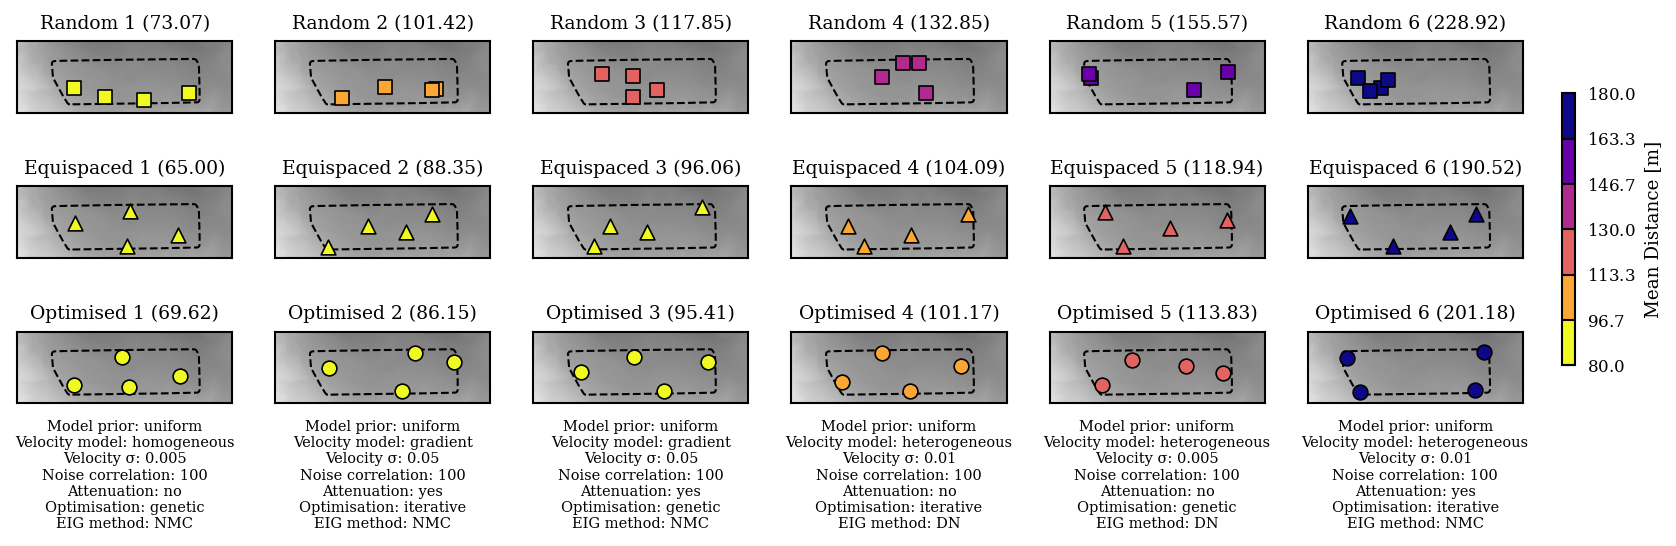

In [23]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# parameters
N = 6

# metric = "EIG"
# vmin, vmax = 0.7, 1.7

metric = "distance_mean"
vmin, vmax = 80.0, 180.0

n_colors = 6
base_cmap = plt.cm.plasma_r
colors = base_cmap(np.linspace(0, 1, n_colors))
cmap = ListedColormap(colors)
boundaries = np.linspace(vmin, vmax, n_colors + 1)
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

def to_numpy(d):
    """Convert a variety of design representations to an (M,2) numpy array (best-effort)."""
    if d is None:
        return np.empty((0, 2))
    # torch tensor
    if hasattr(d, "cpu") and callable(getattr(d, "cpu")):
        try:
            return d.cpu().numpy()
        except Exception as e:
            raise
    if isinstance(d, np.ndarray):
        return d
    try:
        arr = np.asarray(d)
        if arr.ndim == 2:
            return arr
    except Exception as e:
        raise
    try:
        parsed = ast.literal_eval(d)
        return np.array(parsed)
    except Exception as e:
        raise
    return np.array(d)

def select_evenly_spaced_indices(df, col, M):
    """
    Select M row indices from df approximately evenly spaced in df[col] (by quantiles).
    Uses interior quantiles to avoid repeatedly selecting exact min/max when you display the
    extreme 'best' in the first column.
    """
    if M <= 0:
        return []
    series = df[col].astype(float)
    # interior quantiles: M points evenly spaced between 0 and 1, excluding exact endpoints.
    quantiles = np.linspace(0.0, 1.0, M)
    qvals = series.quantile(quantiles).to_numpy()
    selected_idx = []
    for qv in qvals:
        distances = (series - qv).abs()
        if selected_idx:
            distances.iloc[selected_idx] = distances.max() + 1.0
        selected_idx.append(distances.idxmin())
    # return in increasing column order for left-to-right plotting
    selected = df.loc[selected_idx].sort_values(
        col, ascending=True).index.to_list()
    return selected

def _extract_design_from_row(row, group_name):
    """Try common ways to obtain the design object/array from a grouped row."""
    # direct 'design' column
    if "design" in row:
        return row["design"]
    # design_index -> try to find a matching design list in globals
    if "design_index" in row:
        idx = int(row.design_index)
        candidates = [
            f"{group_name.replace('_grouped','')}_design_list",
            "sobol_design_list",
            "random_design_list",
            "design_list",
            "design_stats_list",
        ]
        for name in candidates:
            lst = globals().get(name, None)
            if lst is not None:
                try:
                    return lst[idx]
                except Exception as e:
                    raise
    return None

# assume grouped DataFrames are available: sobol_grouped, random_grouped, design_stats_grouped
groups = [
    ("random_grouped", "Random", "s", 75),
    ("sobol_grouped", "Equispaced", "^", 75),
    ("design_stats_grouped", "Optimised", "o", 60),
]

# create 4 rows: 3 rows of plots + 1 text row for optimized-design choices
fig, axes = plt.subplots(4, N, figsize=((3 * (N-0.5) + 2)*0.7, 1.5 * 4*0.7), sharex=True, sharey=True,
                            gridspec_kw=dict(height_ratios= [1, 1, 1, 0.4]))

for row_idx, (group_name, row_label, marker, best_size) in enumerate(groups):
    group = globals().get(group_name, None)

    # select N evenly spaced percentiles and plot them in columns 1..N
    idxs = select_evenly_spaced_indices(group, metric, N)
    for i in range(N):
        ax = axes[row_idx, i]
        sel_row = group.loc[idxs[i]]
        eig_val = float(sel_row[metric])
        design = _extract_design_from_row(sel_row, group_name)

        d_np = to_numpy(design)
        if d_np.size:
            ax.scatter(
                d_np[:, 0],
                d_np[:, 1],
                color=cmap(norm(eig_val)),
                s=50,
                marker=marker,
                edgecolor="k",
                label=f"{row_label} {i+1}",
            )
        ax.set_title(f"{row_label} {i+1} ({eig_val:.2f})", fontsize=9)

# common styling and topo overlay for the three plot rows only
for ax_row in axes[:-1]:
    for ax in ax_row:
        plot_topography(ax, topo_data, contours=False)

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(300, 1800)
        ax.set_ylim(1200, 1700)
        ax.plot(
            convex_hull_shoulder.shapley_poly.exterior.coords.xy[0],
            convex_hull_shoulder.shapley_poly.exterior.coords.xy[1],
            color="k",
            linewidth=1.0,
            linestyle="--",
            zorder=0,
        )


# -------------------------
# New: add a fourth row containing text with the design choices for the optimized designs
# -------------------------
# human-friendly labels for the metadata keys
label_map = {
    "model_prior": "Model prior",
    "velocity_model": "Velocity model",
    "vel_sigma": "Velocity σ",
    "noise_correlation": "Noise correlation",
    "attenuation": "Attenuation",
    "optimisation": "Optimisation",
    "EIG_method": "EIG method",
    # optional common extras
#     "drop_mean": "Drop mean",
#     "drop_gradient": "Drop gradient",
}

# try to get the selected rows from design_stats_grouped (if available)
ds_group = globals().get("design_stats_grouped", None)
ds_idxs = select_evenly_spaced_indices(ds_group, "EIG", N) if ds_group is not None else []

for i in range(N):
    ax = axes[3, i]
    ax.axis("off")  # text-only
    text_lines = []
    if ds_group is not None and ds_idxs and i < len(ds_idxs):
        try:
            r = ds_group.loc[ds_idxs[i]]
            # prefer to look both in the row and inside a nested 'design_meta' or similar if present
            for k in label_map.keys():
                nice_k = label_map.get(k, k)
                if k in r:
                    val = r[k]
                    text_lines.append(f"{nice_k}: {val}")
                else:
                    # sometimes metadata is stored in a nested dict column; try common names
                    if "design_meta" in r and isinstance(r["design_meta"], dict) and k in r["design_meta"]:
                        text_lines.append(f"{nice_k}: {r['design_meta'][k]}")
        except Exception as e:
            raise

    if not text_lines:
        display_text = "(no design metadata available)"
    else:
        display_text = "\n".join(text_lines)

    # center the text in the axes; adjust fontsize to fit
    ax.text(
        0.5,
        0.5,
        display_text,
        ha="center",
        va="center",
        fontsize=7,
        wrap=True,
        transform=ax.transAxes,
    )

# colorbar at right (adjusted for the taller figure)
cbar_ax = fig.add_axes([0.92, 0.13, 0.007, 0.82])
cbar_ax.set_aspect(20)
fig.colorbar(sm, cax=cbar_ax, label="Mean Distance [m]")


fig.savefig("figures/designs_comparison_shoulder.png", dpi=300, bbox_inches="tight")
fig.savefig("figures/designs_comparison_shoulder.pdf", dpi=300, bbox_inches="tight")

plt.show()